<a href="https://colab.research.google.com/github/Shajjad-142/AI-research/blob/main/shajjad_rice_with_Ens%20with%20MN%20EN_xai_v2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import cv2
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
import torchvision.datasets as datasets
import torchvision.models as models
from torch.utils.data import DataLoader, random_split
import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
import torch.nn.functional as F
from sklearn.manifold import TSNE
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import shap
import warnings

warnings.filterwarnings("ignore")

# CONFIGURATION
BASE_DIR = '/kaggle/input/rice-leaf-diseases-detection'
IMG_SIZE = 224
BATCH_SIZE = 32
# Explicitly check for CUDA
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Device: {DEVICE}")
if torch.cuda.is_available():
    print(f"GPU Model: {torch.cuda.get_device_name(0)}")

Device: cuda
GPU Model: Tesla P100-PCIE-16GB


In [ ]:
# DATA PREPROCESSING
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# SMART DATASET LOADING
# This logic ensures we find the class folders even if nested
DATA_DIR = BASE_DIR
for root, dirs, files in os.walk(BASE_DIR):
    if 'Rice Hispa' in dirs or 'Leaf Blast' in dirs:
        DATA_DIR = root
        break

print(f"Loading data from: {DATA_DIR}")

full_dataset = datasets.ImageFolder(root=DATA_DIR, transform=train_transform)
class_names = full_dataset.classes
num_classes = len(class_names)
print(f"Classes Found: {class_names}")

# Split 80% Train, 20% Test
train_size = int(0.8 * len(full_dataset))
test_size = len(full_dataset) - train_size
train_dataset, test_dataset = random_split(full_dataset, [train_size, test_size])

# Apply test-specific transforms to the test split
test_dataset.dataset.transform = test_transform

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f"Data Ready: {len(train_dataset)} Training images, {len(test_dataset)} Test images")

Loading data from: /kaggle/input/rice-leaf-diseases-detection/Rice_Leaf_AUG/Rice_Leaf_AUG
Classes Found: ['Bacterial Leaf Blight', 'Brown Spot', 'Healthy Rice Leaf', 'Leaf Blast', 'Leaf scald', 'Narrow Brown Leaf Spot', 'Neck_Blast', 'Rice Hispa', 'Sheath Blight']
Data Ready: 9432 Training images, 2358 Test images


In [ ]:
def get_models():
    # 1. MobileNetV2
    m_mobile = models.mobilenet_v2(weights='DEFAULT')
    m_mobile.classifier[1] = nn.Linear(m_mobile.last_channel, num_classes)

    # 2. ResNet18
    m_res18 = models.resnet18(weights='DEFAULT')
    m_res18.fc = nn.Linear(m_res18.fc.in_features, num_classes)

    # 3. ResNet50
    m_res50 = models.resnet50(weights='DEFAULT')
    m_res50.fc = nn.Linear(m_res50.fc.in_features, num_classes)

    # 4. EfficientNet_B0
    m_eff = models.efficientnet_b0(weights='DEFAULT')
    m_eff.classifier[1] = nn.Linear(m_eff.classifier[1].in_features, num_classes)

    # 5. DenseNet121
    m_dense = models.densenet121(weights='DEFAULT')
    m_dense.classifier = nn.Linear(m_dense.classifier.in_features, num_classes)

    # 6. VGG16_BN
    m_vgg = models.vgg16_bn(weights='DEFAULT')
    m_vgg.classifier[6] = nn.Linear(4096, num_classes)

    return [
        ("MobileNetV2", m_mobile),
        ("ResNet18", m_res18),
        ("ResNet50", m_res50),
        ("EfficientNet_B0", m_eff),
        ("DenseNet121", m_dense),
        ("VGG16_BN", m_vgg)
    ]

In [ ]:
def train_model(model, model_name, train_loader, test_loader, epochs=5):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.0005)
    model.to(DEVICE) # Move model to P100

    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

    print(f"\nTraining {model_name}...")
    for epoch in range(epochs):
        model.train()
        running_loss, correct, total = 0.0, 0, 0

        pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}", leave=False)
        for inputs, labels in pbar:
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE) # Move Data to P100

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            pbar.set_postfix({'loss': f'{loss.item():.4f}'})

        # Validation
        model.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0
        with torch.no_grad():
            for inputs, labels in test_loader:
                inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                val_loss += loss.item()
                _, predicted = torch.max(outputs.data, 1)
                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()

        history['train_loss'].append(running_loss / len(train_loader))
        history['train_acc'].append(100 * correct / total)
        history['val_loss'].append(val_loss / len(test_loader))
        history['val_acc'].append(100 * val_correct / val_total)

        print(f"Epoch {epoch+1}: Train Acc: {history['train_acc'][-1]:.2f}% | Val Acc: {history['val_acc'][-1]:.2f}%")

    return model, history, max(history['val_acc'])

# EXECUTE TRAINING
results = {}
model_list = get_models()

for name, model in model_list:
    trained_model, history, best_acc = train_model(model, name, train_loader, test_loader)
    results[name] = {'model': trained_model, 'history': history, 'final_acc': best_acc}

Downloading: "https://download.pytorch.org/models/mobilenet_v2-7ebf99e0.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-7ebf99e0.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 69.7MB/s]


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 130MB/s] 


Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


...

Epoch 4/5:   0%|          | 0/295 [00:00<?, ?it/s]

Epoch 4: Train Acc: 89.15% | Val Acc: 86.85%


Epoch 5/5:   0%|          | 0/295 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7fb2a5783a60>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1664, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1647, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7fb2a5783a60>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1664, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 16

Epoch 5: Train Acc: 90.50% | Val Acc: 88.63%



==================== MobileNetV2 EVALUATION ====================
                        precision    recall  f1-score   support

 Bacterial Leaf Blight       0.95      1.00      0.97       250
            Brown Spot       1.00      0.98      0.99       296
     Healthy Rice Leaf       1.00      1.00      1.00       224
            Leaf Blast       1.00      0.97      0.98       342
            Leaf scald       0.96      0.99      0.97       277
Narrow Brown Leaf Spot       0.97      0.96      0.97       186
            Neck_Blast       1.00      1.00      1.00       191
            Rice Hispa       1.00      0.99      1.00       257
         Sheath Blight       1.00      0.99      0.99       335

              accuracy                           0.99      2358
             macro avg       0.99      0.99      0.99      2358
          weighted avg       0.99      0.99      0.99      2358



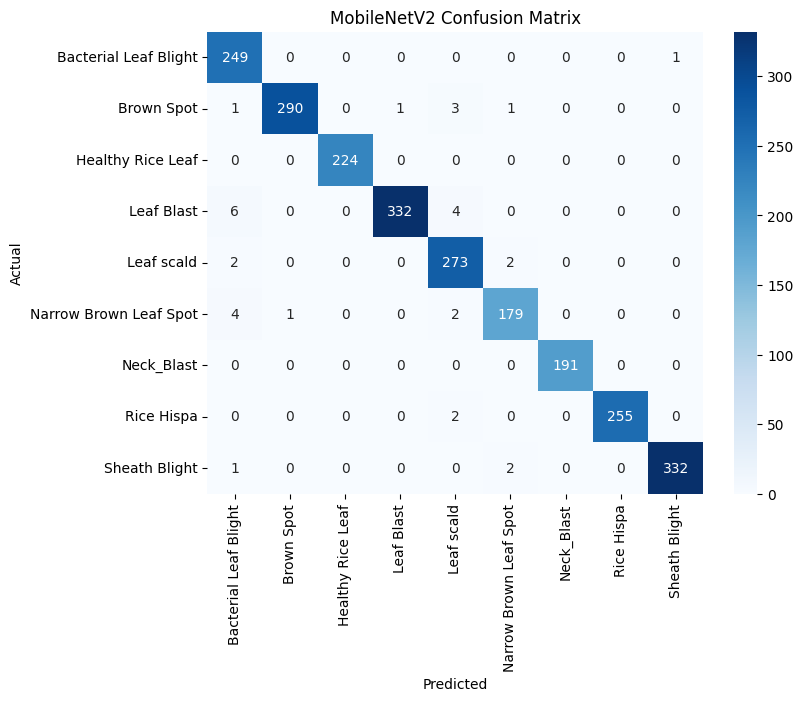


==================== ResNet18 EVALUATION ====================
                        precision    recall  f1-score   support

 Bacterial Leaf Blight       0.91      0.93      0.92       250
            Brown Spot       0.99      0.93      0.96       296
     Healthy Rice Leaf       1.00      1.00      1.00       224
            Leaf Blast       0.96      0.91      0.93       342
            Leaf scald       0.93      0.94      0.93       277
Narrow Brown Leaf Spot       0.92      0.84      0.88       186
            Neck_Blast       1.00      0.99      1.00       191
            Rice Hispa       0.98      1.00      0.99       257
         Sheath Blight       0.89      0.99      0.94       335

              accuracy                           0.95      2358
             macro avg       0.95      0.95      0.95      2358
          weighted avg       0.95      0.95      0.95      2358



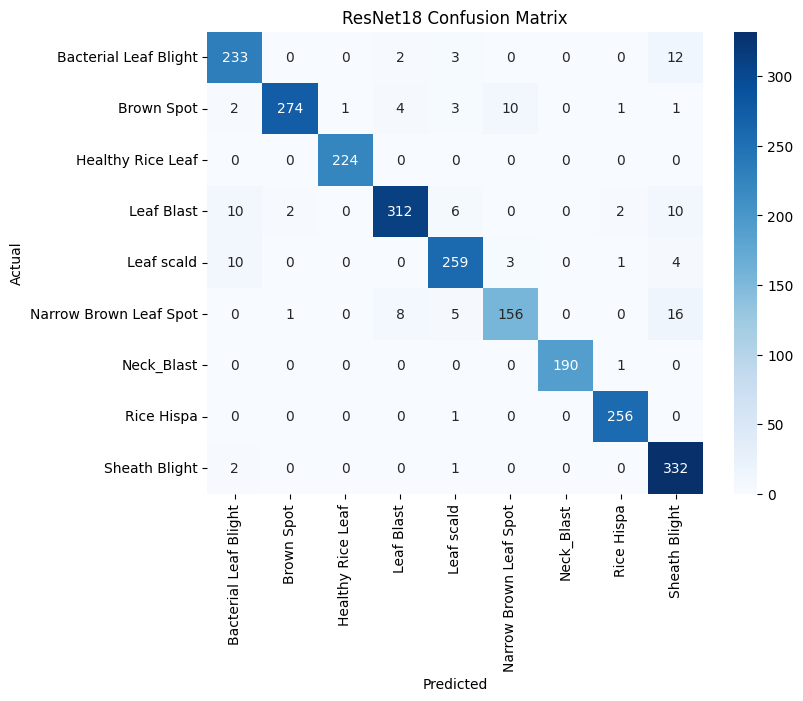


==================== ResNet50 EVALUATION ====================
                        precision    recall  f1-score   support

 Bacterial Leaf Blight       0.91      0.93      0.92       250
            Brown Spot       0.92      1.00      0.96       296
     Healthy Rice Leaf       0.98      0.99      0.98       224
            Leaf Blast       0.98      0.92      0.95       342
            Leaf scald       0.90      0.95      0.93       277
Narrow Brown Leaf Spot       0.98      0.87      0.92       186
            Neck_Blast       1.00      1.00      1.00       191
            Rice Hispa       1.00      0.96      0.98       257
         Sheath Blight       0.96      0.97      0.96       335

              accuracy                           0.96      2358
             macro avg       0.96      0.95      0.96      2358
          weighted avg       0.96      0.96      0.96      2358



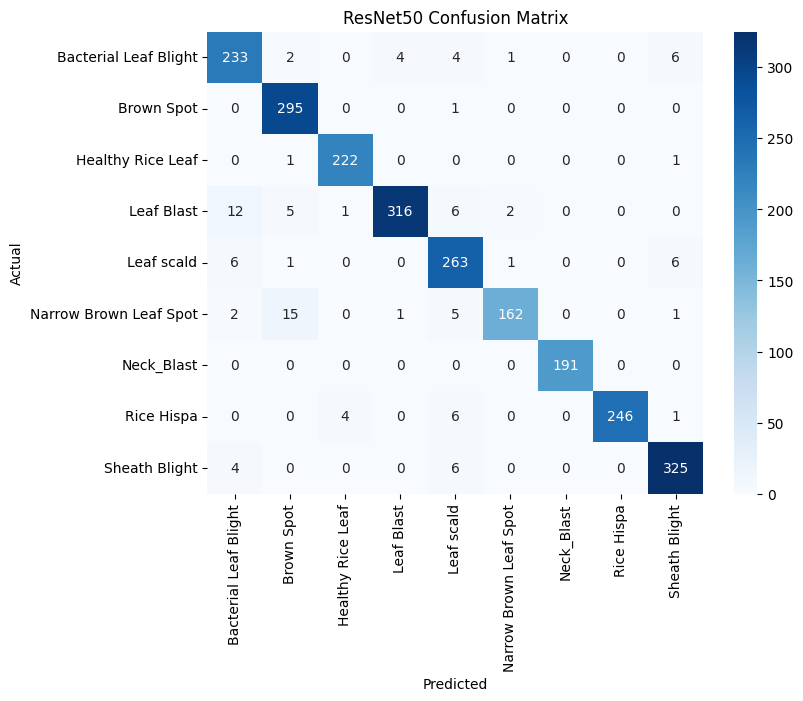


==================== EfficientNet_B0 EVALUATION ====================
                        precision    recall  f1-score   support

 Bacterial Leaf Blight       0.98      0.96      0.97       250
            Brown Spot       0.95      0.98      0.97       296
     Healthy Rice Leaf       1.00      1.00      1.00       224
            Leaf Blast       0.99      0.96      0.98       342
            Leaf scald       0.99      0.98      0.99       277
Narrow Brown Leaf Spot       0.97      0.99      0.98       186
            Neck_Blast       0.99      1.00      1.00       191
            Rice Hispa       1.00      0.99      0.99       257
         Sheath Blight       0.99      0.99      0.99       335

              accuracy                           0.98      2358
             macro avg       0.98      0.99      0.99      2358
          weighted avg       0.98      0.98      0.98      2358



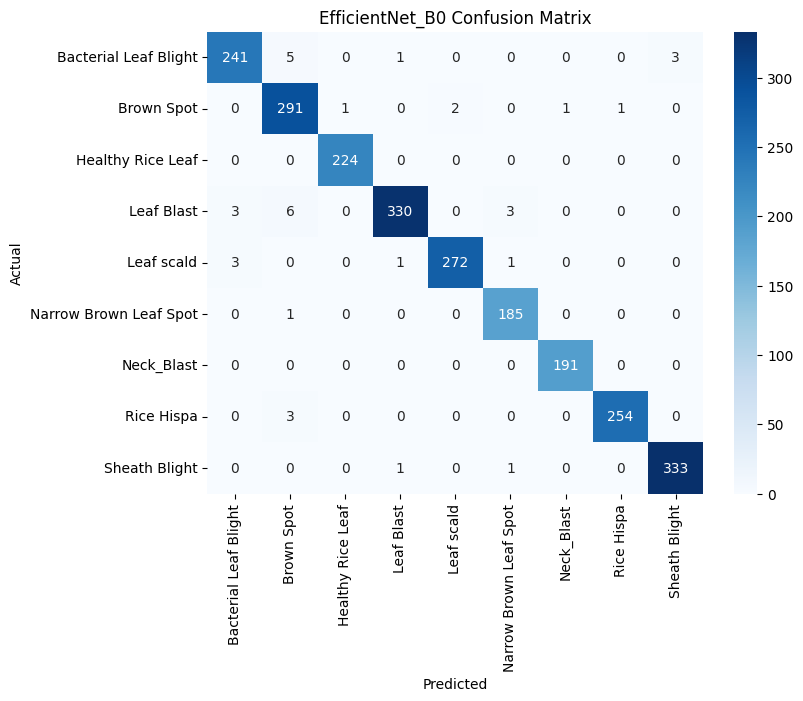


==================== DenseNet121 EVALUATION ====================
                        precision    recall  f1-score   support

 Bacterial Leaf Blight       0.85      0.98      0.91       250
            Brown Spot       0.97      0.97      0.97       296
     Healthy Rice Leaf       1.00      1.00      1.00       224
            Leaf Blast       0.98      0.95      0.97       342
            Leaf scald       0.98      0.91      0.94       277
Narrow Brown Leaf Spot       0.94      0.90      0.92       186
            Neck_Blast       1.00      1.00      1.00       191
            Rice Hispa       1.00      1.00      1.00       257
         Sheath Blight       0.98      0.98      0.98       335

              accuracy                           0.97      2358
             macro avg       0.97      0.97      0.97      2358
          weighted avg       0.97      0.97      0.97      2358



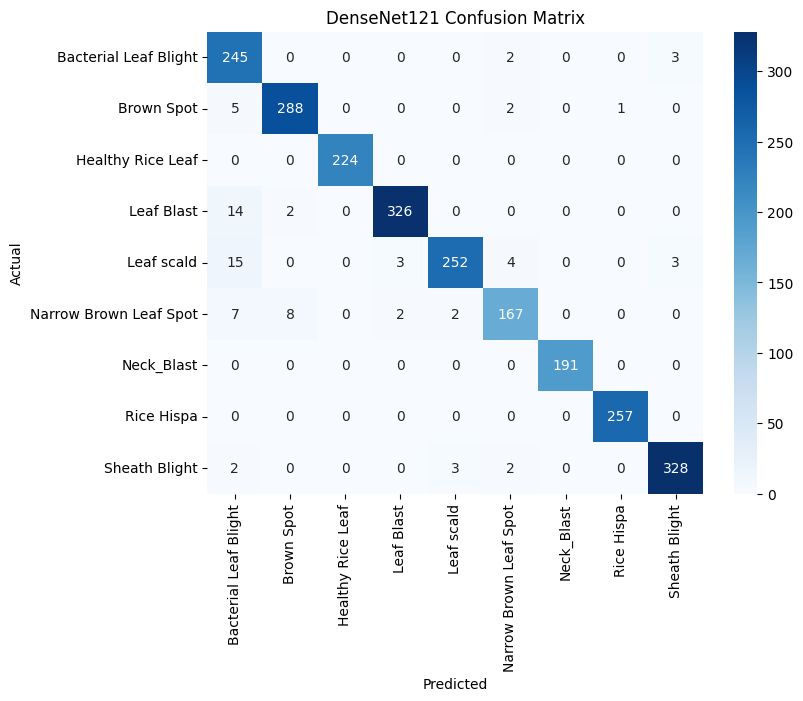


==================== VGG16_BN EVALUATION ====================
                        precision    recall  f1-score   support

 Bacterial Leaf Blight       0.94      0.61      0.74       250
            Brown Spot       0.98      0.87      0.92       296
     Healthy Rice Leaf       0.98      0.96      0.97       224
            Leaf Blast       0.80      0.90      0.85       342
            Leaf scald       0.78      0.83      0.81       277
Narrow Brown Leaf Spot       0.72      0.85      0.78       186
            Neck_Blast       1.00      0.99      1.00       191
            Rice Hispa       0.99      0.95      0.97       257
         Sheath Blight       0.88      0.99      0.93       335

              accuracy                           0.89      2358
             macro avg       0.90      0.89      0.89      2358
          weighted avg       0.90      0.89      0.89      2358



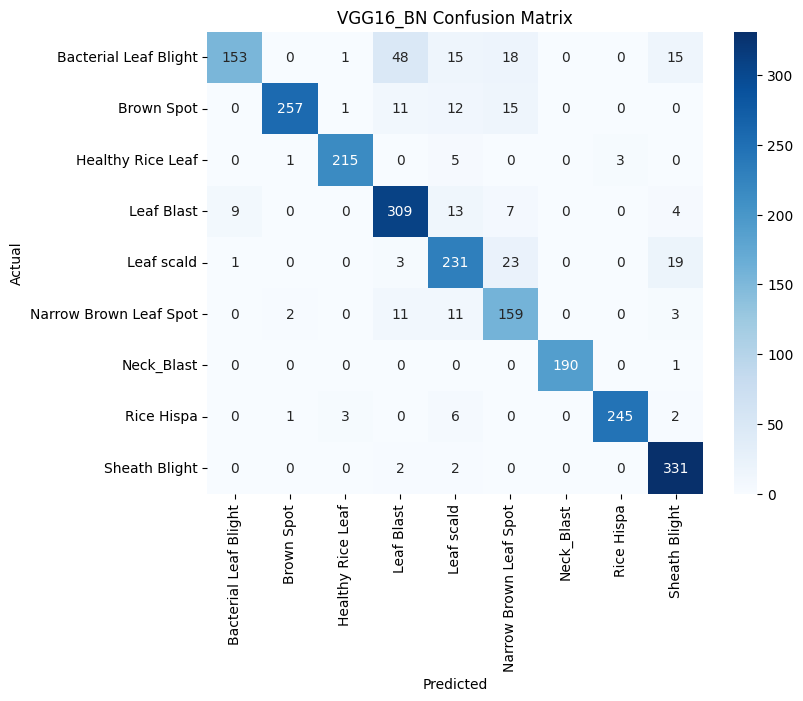

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

def evaluate_individual_metrics(results, test_loader, class_names):
    for name, data in results.items():
        model = data['model']
        model.eval()
        y_true, y_pred = [], []

        with torch.no_grad():
            for inputs, labels in test_loader:
                inputs = inputs.to(DEVICE)
                outputs = model(inputs)
                _, predicted = torch.max(outputs, 1)
                y_true.extend(labels.numpy())
                y_pred.extend(predicted.cpu().numpy())

        print(f"\n{'='*20} {name} EVALUATION {'='*20}")
        print(classification_report(y_true, y_pred, target_names=class_names))

        cm = confusion_matrix(y_true, y_pred)
        plt.figure(figsize=(8, 6))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                    xticklabels=class_names, yticklabels=class_names)
        plt.title(f"{name} Confusion Matrix")
        plt.ylabel('Actual')
        plt.xlabel('Predicted')
        plt.show()

evaluate_individual_metrics(results, test_loader, class_names)

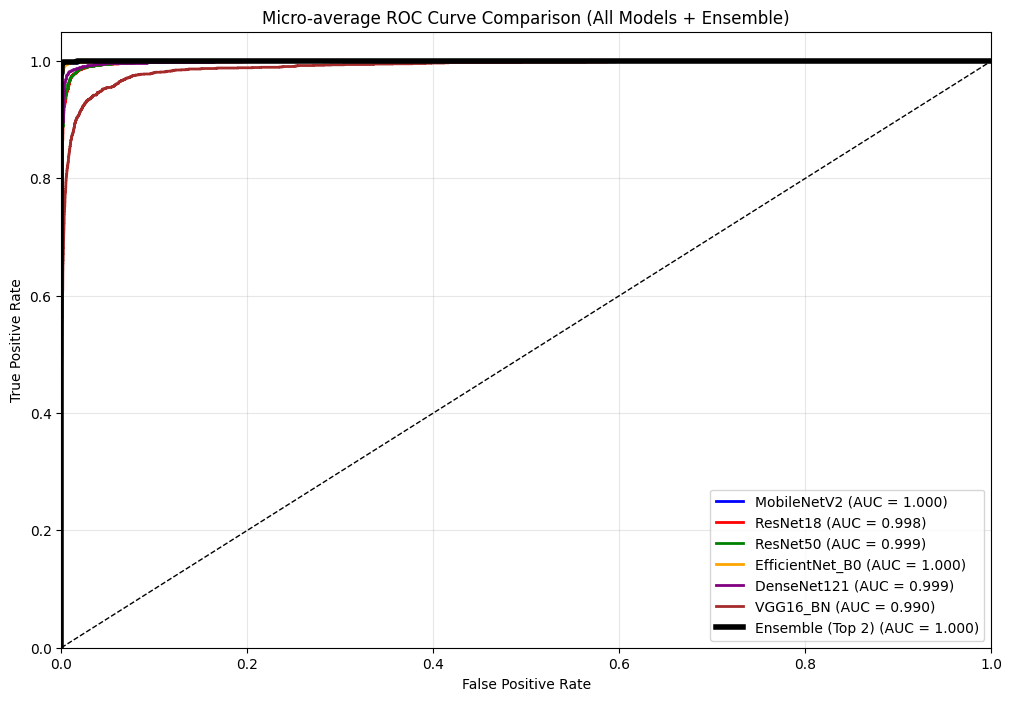

In [ ]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
from itertools import cycle

def plot_model_comparison_roc(results, ensemble_model, test_loader):
    plt.figure(figsize=(12, 8))

    # 1. Prepare data for binarization
    y_true = []
    with torch.no_grad():
        for _, labels in test_loader:
            y_true.extend(labels.numpy())
    y_true = np.array(y_true)
    n_classes = len(np.unique(y_true))
    y_true_bin = label_binarize(y_true, classes=range(n_classes))

    # 2. Setup models to evaluate
    eval_list = list(results.items())
    eval_list.append(("Ensemble (Top 2)", {'model': ensemble_model}))

    colors = cycle(['blue', 'red', 'green', 'orange', 'purple', 'brown', 'black'])

    for (name, data), color in zip(eval_list, colors):
        model = data['model']
        model.eval()
        all_probs = []

        with torch.no_grad():
            for inputs, _ in test_loader:
                inputs = inputs.to(DEVICE)
                outputs = model(inputs)
                probs = F.softmax(outputs, dim=1)
                all_probs.extend(probs.cpu().numpy())

        all_probs = np.array(all_probs)

        # 3. Compute Micro-average ROC
        # ravel() flattens the arrays to treat multiclass as a single binary problem
        fpr, tpr, _ = roc_curve(y_true_bin.ravel(), all_probs.ravel())
        roc_auc = auc(fpr, tpr)

        lw = 2 if "Ensemble" not in name else 4  # Make Ensemble line thicker
        plt.plot(fpr, tpr, color=color, lw=lw,
                 label=f'{name} (AUC = {roc_auc:0.3f})')

    plt.plot([0, 1], [0, 1], 'k--', lw=1)
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Micro-average ROC Curve Comparison (All Models + Ensemble)')
    plt.legend(loc="lower right")
    plt.grid(True, alpha=0.3)
    plt.show()

# Run comparison
plot_model_comparison_roc(results, ensemble_model, test_loader)

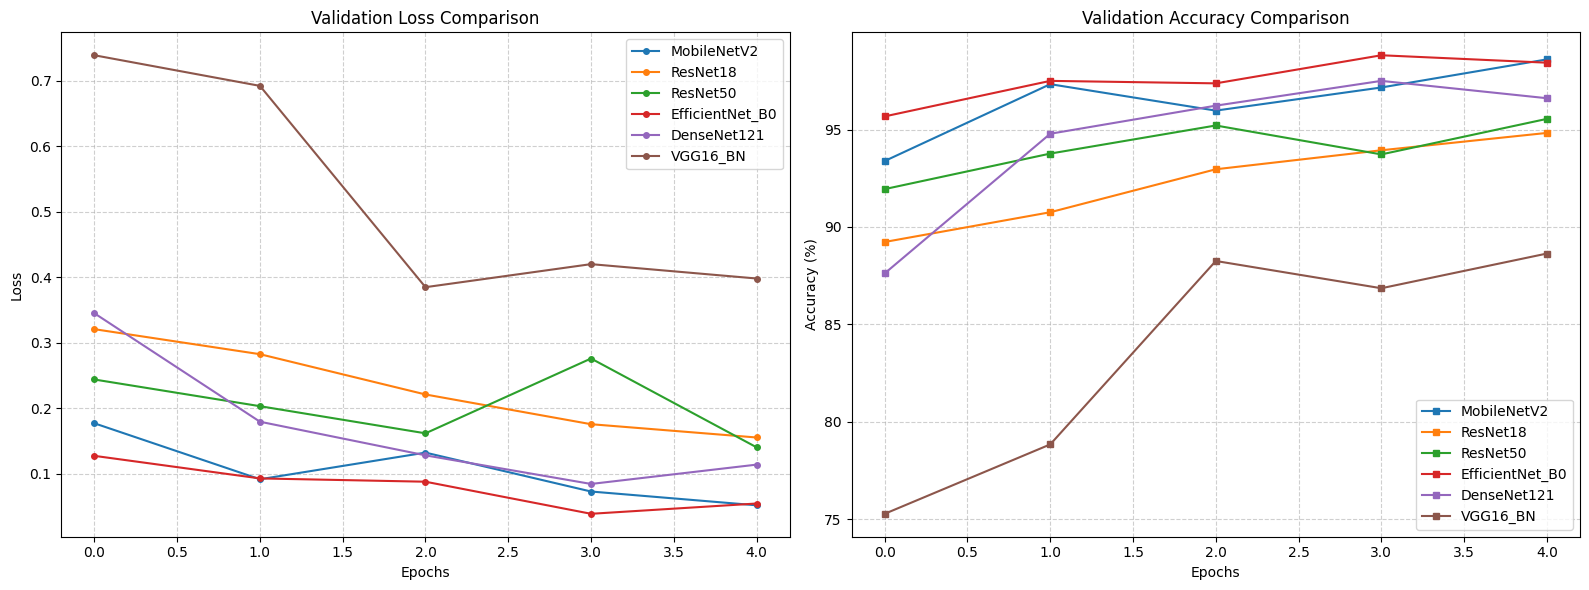

In [ ]:
# COMPARE TRAINING CURVES
plt.figure(figsize=(16, 6))

# Subplot 1: Validation Loss (Lower is better)
plt.subplot(1, 2, 1)
for name, data in results.items():
    plt.plot(data['history']['val_loss'], label=name, marker='o', markersize=4)
plt.title("Validation Loss Comparison")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

# Subplot 2: Validation Accuracy (Higher is better)
plt.subplot(1, 2, 2)
for name, data in results.items():
    plt.plot(data['history']['val_acc'], label=name, marker='s', markersize=4)
plt.title("Validation Accuracy Comparison")
plt.xlabel("Epochs")
plt.ylabel("Accuracy (%)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

In [ ]:
# SELECT TOP 2 AND ENSEMBLE
sorted_models = sorted(results.items(), key=lambda x: x[1]['final_acc'], reverse=True)
top_2 = sorted_models[:2]

class EnsembleModel(nn.Module):
    def __init__(self, modelA, modelB):
        super(EnsembleModel, self).__init__()
        self.modelA = modelA
        self.modelB = modelB
    def forward(self, x):
        return (self.modelA(x) + self.modelB(x)) / 2

ensemble_model = EnsembleModel(top_2[0][1]['model'], top_2[1][1]['model']).to(DEVICE).eval()

# Evaluation Loop
y_true, y_pred = [], []
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(DEVICE)
        outputs = ensemble_model(inputs)
        y_true.extend(labels.numpy())
        y_pred.extend(torch.max(outputs, 1)[1].cpu().numpy())

print(f"\nEnsemble Accuracy: {accuracy_score(y_true, y_pred)*100:.2f}%")
print(classification_report(y_true, y_pred, target_names=class_names))

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7fb2a5783a60>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1664, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1647, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7fb2a5783a60>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1664, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 16


Ensemble Accuracy: 99.45%
                        precision    recall  f1-score   support

 Bacterial Leaf Blight       0.97      1.00      0.98       250
            Brown Spot       1.00      0.99      1.00       296
     Healthy Rice Leaf       1.00      1.00      1.00       224
            Leaf Blast       1.00      0.98      0.99       342
            Leaf scald       0.99      1.00      0.99       277
Narrow Brown Leaf Spot       0.99      0.99      0.99       186
            Neck_Blast       1.00      1.00      1.00       191
            Rice Hispa       1.00      1.00      1.00       257
         Sheath Blight       1.00      1.00      1.00       335

              accuracy                           0.99      2358
             macro avg       0.99      1.00      0.99      2358
          weighted avg       0.99      0.99      0.99      2358



Evaluating Ensemble:   0%|          | 0/74 [00:00<?, ?it/s]


--- ENSEMBLE ERROR ANALYSIS ---
Overall Accuracy: 99.45%

                        precision    recall  f1-score   support

 Bacterial Leaf Blight       0.97      1.00      0.98       250
            Brown Spot       1.00      0.99      1.00       296
     Healthy Rice Leaf       1.00      1.00      1.00       224
            Leaf Blast       1.00      0.98      0.99       342
            Leaf scald       0.99      1.00      0.99       277
Narrow Brown Leaf Spot       0.99      0.99      0.99       186
            Neck_Blast       1.00      1.00      1.00       191
            Rice Hispa       1.00      1.00      1.00       257
         Sheath Blight       1.00      1.00      1.00       335

              accuracy                           0.99      2358
             macro avg       0.99      1.00      0.99      2358
          weighted avg       0.99      0.99      0.99      2358



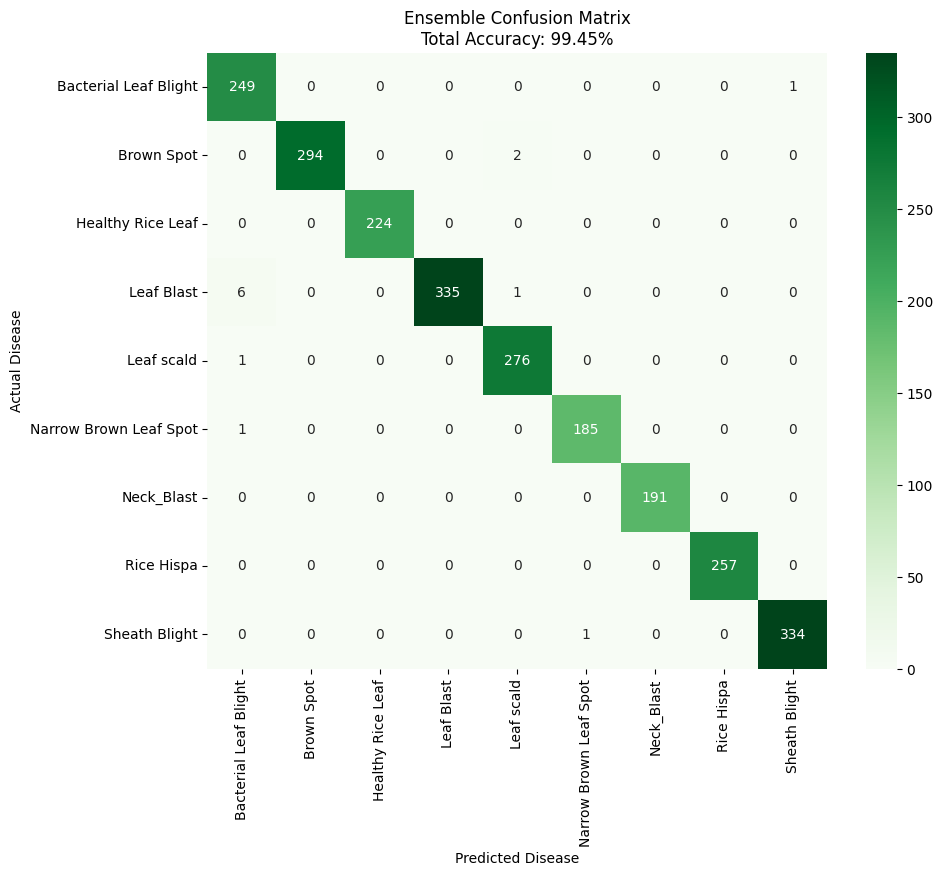

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns

# 1. GENERATE PREDICTIONS
ensemble_model.eval()
y_true_ens, y_pred_ens = [], []

with torch.no_grad():
    for inputs, labels in tqdm(test_loader, desc="Evaluating Ensemble"):
        inputs = inputs.to(DEVICE)
        outputs = ensemble_model(inputs)
        _, predicted = torch.max(outputs, 1)

        y_true_ens.extend(labels.cpu().numpy())
        y_pred_ens.extend(predicted.cpu().numpy())

# 2. PRINT CLASSIFICATION REPORT
# This shows Precision, Recall, and F1-Score per class
print("\n--- ENSEMBLE ERROR ANALYSIS ---")
ens_acc = accuracy_score(y_true_ens, y_pred_ens)
print(f"Overall Accuracy: {ens_acc*100:.2f}%\n")
print(classification_report(y_true_ens, y_pred_ens, target_names=class_names))

# 3. PLOT CONFUSION MATRIX
cm_ens = confusion_matrix(y_true_ens, y_pred_ens)
plt.figure(figsize=(10, 8))
sns.heatmap(cm_ens, annot=True, fmt='d', cmap='Greens',
            xticklabels=class_names, yticklabels=class_names)
plt.title(f"Ensemble Confusion Matrix\nTotal Accuracy: {ens_acc:.2%}")
plt.ylabel('Actual Disease')
plt.xlabel('Predicted Disease')
plt.show()

Clearing all existing hooks...
Extracting features from Ensemble (EfficientNet_B0 + MobileNetV2)...
Feature A Shape: (320, 1280)
Feature B Shape: (320, 1280)
Running t-SNE on (320, 2560)...


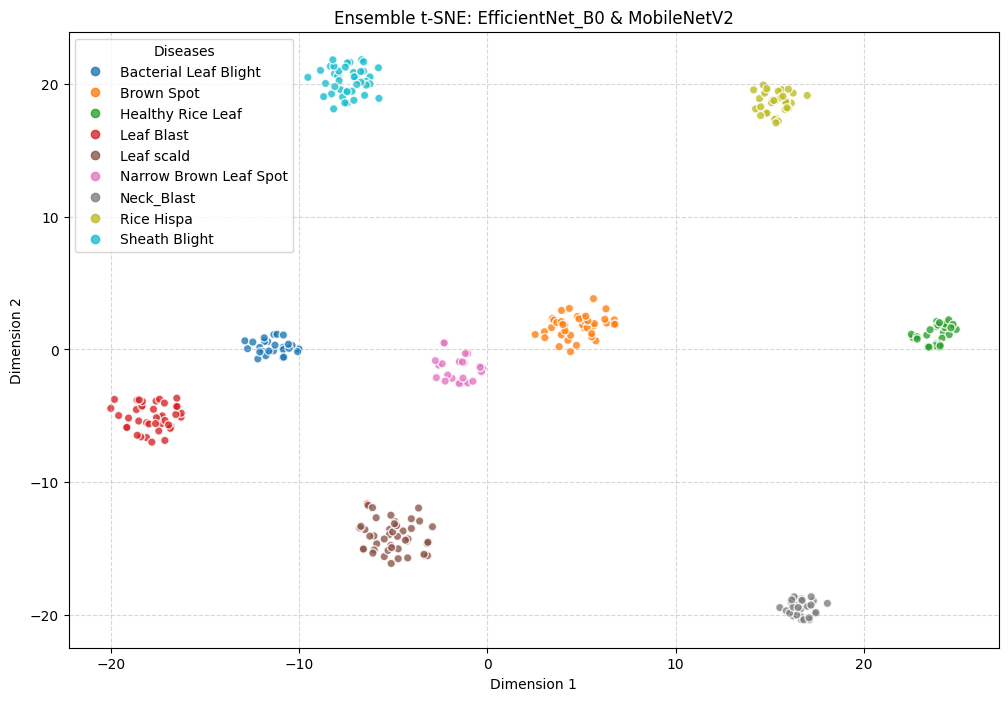

In [ ]:
from sklearn.manifold import TSNE
import torch.nn.functional as F
import numpy as np
import torch.nn as nn

# =========================================================================
# 1. FORCE CLEANUP (The Fix)
# =========================================================================
def clear_all_hooks(model):
    """Recursively removes all hooks from all modules in the model."""
    for module in model.modules():
        if hasattr(module, '_forward_hooks'):
            module._forward_hooks.clear()
        if hasattr(module, '_forward_pre_hooks'):
            module._forward_pre_hooks.clear()

# Apply cleanup to ensure no "zombie" hooks from previous errors exist
print("Clearing all existing hooks...")
clear_all_hooks(ensemble_model)

# =========================================================================
# 2. SETUP & EXTRACTION
# =========================================================================
features_list_A = []
features_list_B = []
labels_list = []

def hook_fn_A(module, input, output):
    # Handle tuple outputs
    if isinstance(output, tuple): output = output[0]

    # Force flattening: (Batch, C, H, W) -> (Batch, C*H*W) or (Batch, C)
    if output.dim() > 2:
        if output.dim() == 4:
            output = F.adaptive_avg_pool2d(output, (1, 1))
        output = output.view(output.size(0), -1)

    feat = output.cpu().detach().numpy()
    features_list_A.append(feat)

def hook_fn_B(module, input, output):
    if isinstance(output, tuple): output = output[0]
    if output.dim() > 2:
        if output.dim() == 4:
            output = F.adaptive_avg_pool2d(output, (1, 1))
        output = output.view(output.size(0), -1)

    feat = output.cpu().detach().numpy()
    features_list_B.append(feat)

def register_hook_safe(model, hook_fn):
    # Heuristic to find the best layer for feature extraction
    if hasattr(model, 'avgpool') and isinstance(model.avgpool, nn.Module):
        return model.avgpool.register_forward_hook(hook_fn)
    elif hasattr(model, 'features'):
        return model.features.register_forward_hook(hook_fn)
    elif hasattr(model, 'classifier'):
         # Hook the input to the classifier
        if isinstance(model.classifier, nn.Sequential):
            return model.classifier[0].register_forward_pre_hook(lambda m, i: hook_fn(m, i, i[0]))
        return model.classifier.register_forward_pre_hook(lambda m, i: hook_fn(m, i, i[0]))
    else:
        return list(model.children())[-2].register_forward_hook(hook_fn)

# Register Fresh Hooks
handleA = register_hook_safe(ensemble_model.modelA, hook_fn_A)
handleB = register_hook_safe(ensemble_model.modelB, hook_fn_B)

print(f"Extracting features from Ensemble ({top_2[0][0]} + {top_2[1][0]})...")
ensemble_model.eval()
max_samples = 300
count = 0

# Use clean loader to avoid multiprocessing hangs
loader = test_loader_clean if 'test_loader_clean' in locals() else test_loader

with torch.no_grad():
    for inputs, labels in loader:
        if count >= max_samples: break
        inputs = inputs.to(DEVICE)
        _ = ensemble_model(inputs)
        labels_list.extend(labels.numpy())
        count += len(labels)

# Remove hooks immediately
handleA.remove()
handleB.remove()

# =========================================================================
# 3. VISUALIZATION
# =========================================================================
try:
    # Concatenate lists
    feat_A = np.concatenate(features_list_A, axis=0)
    feat_B = np.concatenate(features_list_B, axis=0)

    # Check dimensions (Debugging)
    print(f"Feature A Shape: {feat_A.shape}")
    print(f"Feature B Shape: {feat_B.shape}")

    # Combine features
    features_combined = np.hstack((feat_A, feat_B))
    labels_array = np.array(labels_list)

    print(f"Running t-SNE on {features_combined.shape}...")
    tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000)
    tsne_results = tsne.fit_transform(features_combined)

    plt.figure(figsize=(12, 8))
    scatter = plt.scatter(tsne_results[:, 0], tsne_results[:, 1],
                          c=labels_array, cmap='tab10', alpha=0.8, edgecolors='w')

    legend = plt.legend(*scatter.legend_elements(), title="Diseases", loc="best")
    for i, text in enumerate(legend.get_texts()):
        if i < len(class_names):
            text.set_text(class_names[i])

    plt.title(f"Ensemble t-SNE: {top_2[0][0]} & {top_2[1][0]}")
    plt.xlabel("Dimension 1")
    plt.ylabel("Dimension 2")
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()

except ValueError as e:
    print(f"Error during concatenation: {e}")
    # Inspect first elements if error persists
    if len(features_list_A) > 0:
        print(f"First item shape A: {features_list_A[0].shape}")
    if len(features_list_B) > 0:
        print(f"First item shape B: {features_list_B[0].shape}")

Generating Ensemble Grad-CAM (EfficientNet_B0 + MobileNetV2)...


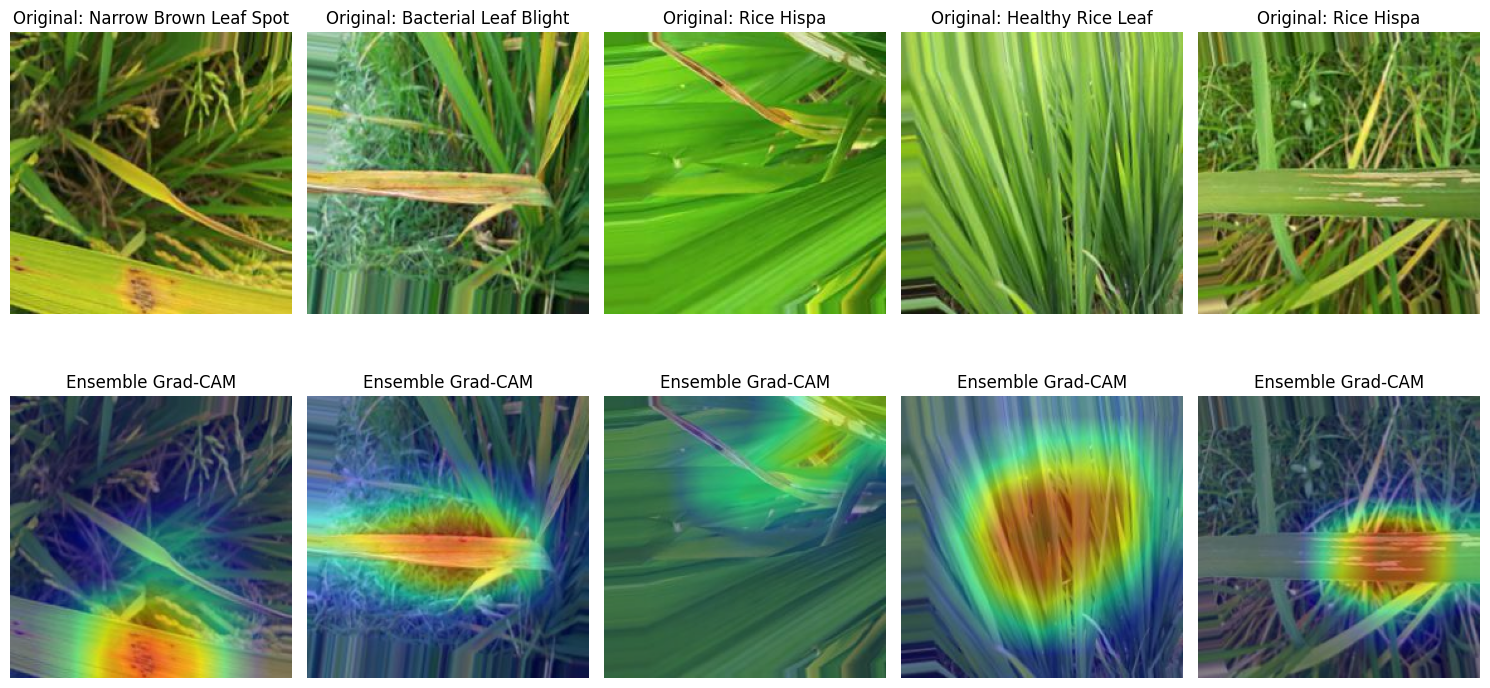

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F

# 1. DEFINE GRAD-CAM CLASS
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.gradients = None
        self.activations = None

        # Hooks
        target_layer.register_forward_hook(self.save_activation)
        target_layer.register_backward_hook(self.save_gradient)

    def save_activation(self, module, input, output):
        self.activations = output

    def save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0]

    def __call__(self, x, class_idx=None):
        self.model.zero_grad()
        output = self.model(x)

        if class_idx is None:
            class_idx = torch.argmax(output, dim=1)

        score = output[:, class_idx].sum()
        score.backward()

        # Pool gradients
        pooled_gradients = torch.mean(self.gradients, dim=[0, 2, 3])

        # Weight activations
        activations = self.activations
        for i in range(activations.shape[1]):
            activations[:, i, :, :] *= pooled_gradients[i]

        heatmap = torch.mean(activations, dim=1).squeeze()
        heatmap = F.relu(heatmap)
        heatmap /= torch.max(heatmap) if torch.max(heatmap) > 0 else 1

        return heatmap.cpu().detach().numpy()

# 2. SELECT TARGET LAYERS FOR SUB-MODELS
# We need to know which layer to hook for Model A and Model B
def get_target_layer(model, model_name):
    if "ResNet" in model_name:
        return model.layer4[-1]
    elif "MobileNet" in model_name or "EfficientNet" in model_name:
        # For MobileNet/EfficientNet, features[-1] is usually the last Conv block
        return model.features[-1]
    elif "DenseNet" in model_name:
        return model.features.denseblock4
    elif "VGG" in model_name:
        return model.features[-1]
    else:
        return list(model.children())[-2]

# Setup GradCAM for both parts of the ensemble
name_A = top_2[0][0]
model_A = top_2[0][1]['model']
target_A = get_target_layer(model_A, name_A)
gcam_A = GradCAM(model_A, target_A)

name_B = top_2[1][0]
model_B = top_2[1][1]['model']
target_B = get_target_layer(model_B, name_B)
gcam_B = GradCAM(model_B, target_B)

# 3. GENERATE ENSEMBLE HEATMAPS
print(f"Generating Ensemble Grad-CAM ({name_A} + {name_B})...")

# Get a batch of images
batch = next(iter(test_loader))
images, labels = batch
images = images.to(DEVICE)
vis_images = images[:5]
vis_labels = labels[:5]

plt.figure(figsize=(15, 8))

for i in range(len(vis_images)):
    img_tensor = vis_images[i].unsqueeze(0)

    # Get Heatmaps from both models
    # Note: We must enable grad for GradCAM to work
    with torch.enable_grad():
        heatmap_A = gcam_A(img_tensor)
        heatmap_B = gcam_B(img_tensor)

    # Average the heatmaps
    heatmap_ens = (heatmap_A + heatmap_B) / 2.0

    # Denormalize image for display
    img_np = vis_images[i].cpu().numpy().transpose(1, 2, 0)
    img_np = img_np * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
    img_np = np.clip(img_np, 0, 1)

    # Overlay
    heatmap_ens = cv2.resize(heatmap_ens, (224, 224))
    heatmap_ens = np.uint8(255 * heatmap_ens)
    heatmap_ens = cv2.applyColorMap(heatmap_ens, cv2.COLORMAP_JET)
    heatmap_ens = cv2.cvtColor(heatmap_ens, cv2.COLOR_BGR2RGB)

    superimposed = np.uint8(255 * img_np) * 0.6 + heatmap_ens * 0.4
    superimposed = np.clip(superimposed, 0, 255).astype(np.uint8)

    plt.subplot(2, 5, i+1)
    plt.imshow(img_np)
    plt.title(f"Original: {class_names[vis_labels[i]]}")
    plt.axis('off')

    plt.subplot(2, 5, i+6)
    plt.imshow(superimposed)
    plt.title(f"Ensemble Grad-CAM")
    plt.axis('off')

plt.tight_layout()
plt.show()

Ensemble SHAP Image 1 (Pred: Narrow Brown Leaf Spot)


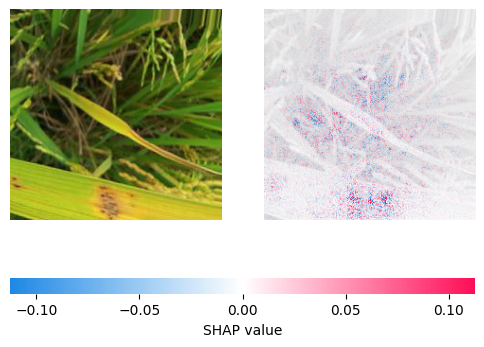

Ensemble SHAP Image 2 (Pred: Bacterial Leaf Blight)


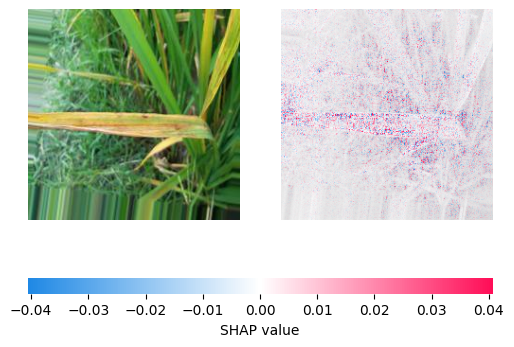

Ensemble SHAP Image 3 (Pred: Rice Hispa)


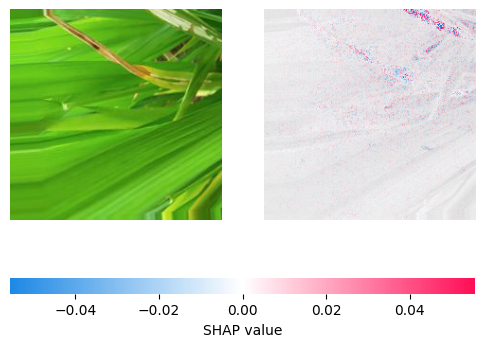

In [ ]:
import shap

# 1. SETUP
ensemble_model.eval()
background = next(iter(train_loader))[0][:30].to(DEVICE)
to_explain = next(iter(test_loader))[0][:3].to(DEVICE)

# 2. CALC
explainer = shap.GradientExplainer(ensemble_model, background)
# This returns a list of arrays (one per class)
shap_values = explainer.shap_values(to_explain)

# 3. PLOT WITH YOUR FIX
for i in range(len(to_explain)):
    # Assuming we want the top predicted class for visualization
    with torch.no_grad():
        pred_idx = torch.argmax(ensemble_model(to_explain[i:i+1])).item()

    # Slicing the 5D logic: [image_index, channels, h, w, class_index]
    # Then transpose to (H, W, C) and add batch dim (1, H, W, C)
    shap_val_class = shap_values[i, :, :, :, pred_idx]
    shap_val_display = np.expand_dims(np.transpose(shap_val_class, (1, 2, 0)), axis=0)

    # Denormalize background
    img_np = to_explain[i].cpu().numpy().transpose(1, 2, 0)
    img_np = np.clip(img_np * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406]), 0, 1)

    print(f"Ensemble SHAP Image {i+1} (Pred: {class_names[pred_idx]})")
    shap.image_plot([shap_val_display], np.array([img_np]))